In [ ]:
%load_ext autoreload
%autoreload 2

# 1. 数据加载与清洗

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
import os
from dotenv import load_dotenv
import utils_z
warnings.filterwarnings('ignore')

In [11]:
load_dotenv()
conn = utils_z.get_conn(
    os.getenv("DB_NAME"),
    os.getenv("DB_USER"),
    os.getenv("DB_PASSWORD"),
    os.getenv("DB_HOST"),
    os.getenv("DB_PORT")
)
print("数据库连接成功")

plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False  

数据库连接成功


In [14]:
# ── 拉取所有指标列（排除几何和元数据列）──
METRIC_COLS = [
    # Block几何属性
    'area_m2', 'elongation', 'compactness', 'convexity', 'rectangularity',
    # 密度与数量
    'lod1_building_count', 'bcr', 'far', 'bcd', 'osr',
    # 高度
    'avh', 'avh_w', 'hsd', 'hcv', 'h_max', 'h_range',
    # 体量与平面
    'total_volume', 'avg_volume', 'avg_footprint', 'footprint_cv',
    # 建筑形状
    'avg_complexity', 'avg_rectangularity', 'avg_convexity',
    # 分布
    'avg_orientation', 'orientation_entropy', 'avg_nn_distance'
]

query = f"""
    SELECT city, {', '.join(METRIC_COLS)}
    FROM summary.lod1_valid_blocks
"""
df_raw = pd.read_sql(query, conn)

print(f"原始数据: {df_raw.shape[0]} 行 × {df_raw.shape[1]} 列")

# ── 清洗：过滤含NULL的行 ──
df = df_raw[['city'] + METRIC_COLS].dropna(subset=METRIC_COLS)
print(f"过滤NULL后: {df.shape[0]} 行（丢弃 {df_raw.shape[0]-df.shape[0]} 行）")

# ── 基础统计概览 ──
with pd.option_context('display.max_columns', None):
    display(df.describe().round(3))

原始数据: 208344 行 × 27 列
过滤NULL后: 204205 行（丢弃 4139 行）


,area_m2,elongation,compactness,convexity,rectangularity,lod1_building_count,bcr,far,bcd,osr,avh,avh_w,hsd,hcv,h_max,h_range,total_volume,avg_volume,avg_footprint,footprint_cv,avg_complexity,avg_rectangularity,avg_convexity,avg_orientation,orientation_entropy,avg_nn_distance
count,204205.000,204205.000,204205.000,204205.000,204205.000,204205.000,204205.000,204205.000,204205.000,204205.000,204205.000,204205.000,204205.000,204205.000,204205.000,204205.000,204205.000,204205.000,204205.000,204205.000,204205.000,204205.000,204205.000,204205.000,204205.000,204205.000
mean,15964.237,2.583,0.667,0.968,0.827,32.651,0.331,1.237,33.304,1.888,9.590,11.548,3.819,0.366,17.504,13.195,53921.984,3451.131,194.176,0.886,2.558,0.868,0.964,84.977,0.982,16.933
std,28520.171,0.705,0.104,0.066,0.138,34.011,0.133,1.468,23.100,22.203,6.970,9.583,5.212,0.222,15.416,14.431,112800.145,17992.134,423.219,0.547,4.609,0.070,0.033,42.170,0.476,14.518
min,1000.143,1.201,0.048,0.153,0.107,2.000,0.000,0.000,0.075,0.005,0.114,0.113,0.000,0.000,0.116,0.000,1.926,0.854,1.019,0.000,1.016,0.168,0.251,0.000,0.000,0.000
25%,4355.139,2.091,0.612,0.970,0.739,13.000,0.228,0.522,15.478,0.391,6.119,7.184,1.605,0.217,9.310,5.730,12516.801,538.118,73.308,0.535,1.482,0.823,0.955,51.317,0.662,10.578
50%,8366.556,2.450,0.694,0.996,0.860,23.000,0.324,0.855,28.563,0.766,7.679,8.557,2.416,0.322,12.400,8.570,25127.846,879.031,102.084,0.747,1.564,0.877,0.972,84.494,0.937,13.076
75%,18954.435,2.898,0.746,1.000,0.939,41.000,0.432,1.435,47.044,1.441,10.505,13.127,4.267,0.458,21.100,16.175,52178.164,2106.968,165.418,1.104,1.729,0.921,0.983,119.194,1.285,18.325
max,1085975.635,15.986,0.999,1.000,1.000,743.000,0.960,46.595,370.041,4547.712,290.500,313.620,294.277,2.937,472.000,416.170,5198538.450,1505792.110,34020.944,8.939,349.208,1.000,1.000,179.941,2.774,670.688


In [17]:
# ══════════════════════════════════════════════
#  精准截断：只对无界高偏指标做上截
#  不对比值型指标做下截
# ══════════════════════════════════════════════

# 只需要上截的指标（无界、右偏）
UPPER_CLIP_COLS = [
    'area_m2', 'lod1_building_count', 'far', 'bcd', 'osr',
    'avh', 'avh_w', 'hsd', 'h_max', 'h_range',
    'total_volume', 'avg_volume', 'avg_footprint', 'footprint_cv',
    'avg_complexity', 'avg_nn_distance'
]

# 需要下截的指标（下尾确实存在异常低值）
LOWER_CLIP_COLS = [
    'area_m2', 'avh', 'avh_w', 'h_max',
    'avg_footprint', 'avg_nn_distance'
]

upper_bounds = df[UPPER_CLIP_COLS].quantile(0.99)
lower_bounds = df[LOWER_CLIP_COLS].quantile(0.01)

mask = pd.Series(True, index=df.index)

for col in UPPER_CLIP_COLS:
    mask &= df[col] <= upper_bounds[col]

for col in LOWER_CLIP_COLS:
    mask &= df[col] >= lower_bounds[col]

df_clean = df[mask].copy()

n_raw   = len(df)
n_clean = len(df_clean)
print(f"原始行数:   {n_raw:,}")
print(f"截断后行数: {n_clean:,}")
print(f"删除行数:   {n_raw - n_clean:,}  ({(n_raw - n_clean)/n_raw*100:.1f}%)")

原始行数:   204,205
截断后行数: 181,858
删除行数:   22,347  (10.9%)


In [18]:
# ── 基础统计概览 ──
with pd.option_context('display.max_columns', None):
    display(df_clean.describe().round(3))

,area_m2,elongation,compactness,convexity,rectangularity,lod1_building_count,bcr,far,bcd,osr,avh,avh_w,hsd,hcv,h_max,h_range,total_volume,avg_volume,avg_footprint,footprint_cv,avg_complexity,avg_rectangularity,avg_convexity,avg_orientation,orientation_entropy,avg_nn_distance
count,181858.000,181858.000,181858.000,181858.000,181858.000,181858.000,181858.000,181858.000,181858.000,181858.000,181858.000,181858.000,181858.000,181858.000,181858.000,181858.000,181858.000,181858.000,181858.000,181858.000,181858.000,181858.000,181858.000,181858.000,181858.000,181858.000
mean,12845.082,2.580,0.669,0.970,0.831,30.572,0.334,1.129,33.549,1.083,9.068,10.736,3.383,0.357,16.200,12.087,40326.484,1926.426,151.746,0.851,2.224,0.870,0.965,84.438,0.983,15.515
std,13966.424,0.683,0.100,0.062,0.136,24.559,0.125,0.896,20.725,1.021,4.605,5.893,2.940,0.204,10.137,9.817,49040.465,3068.822,167.156,0.471,3.193,0.067,0.029,42.195,0.466,8.302
min,1280.377,1.204,0.084,0.180,0.122,2.000,0.017,0.096,0.377,0.036,3.725,4.045,0.000,0.000,5.170,0.000,438.483,162.042,36.612,0.000,1.233,0.247,0.340,0.000,0.000,6.488
25%,4321.491,2.095,0.615,0.973,0.746,14.000,0.235,0.530,16.935,0.408,6.175,7.212,1.621,0.218,9.310,5.800,12734.737,550.202,74.400,0.536,1.481,0.827,0.956,50.590,0.662,10.643
50%,7883.812,2.454,0.694,0.997,0.864,23.000,0.326,0.845,29.659,0.775,7.644,8.496,2.391,0.318,12.262,8.500,24475.018,866.206,101.150,0.734,1.557,0.879,0.972,83.583,0.937,12.941
75%,17398.807,2.891,0.746,1.000,0.942,40.000,0.430,1.389,47.222,1.408,10.191,12.710,4.078,0.444,20.500,15.500,46709.893,1910.561,156.670,1.065,1.701,0.922,0.982,118.848,1.280,17.586
max,132159.804,9.207,0.998,1.000,1.000,161.000,0.881,5.989,103.270,9.640,33.500,45.177,21.355,2.054,74.390,64.350,491745.030,43139.594,1821.250,2.785,23.437,1.000,1.000,179.941,2.774,77.668


# 2. 各指标分布可视化

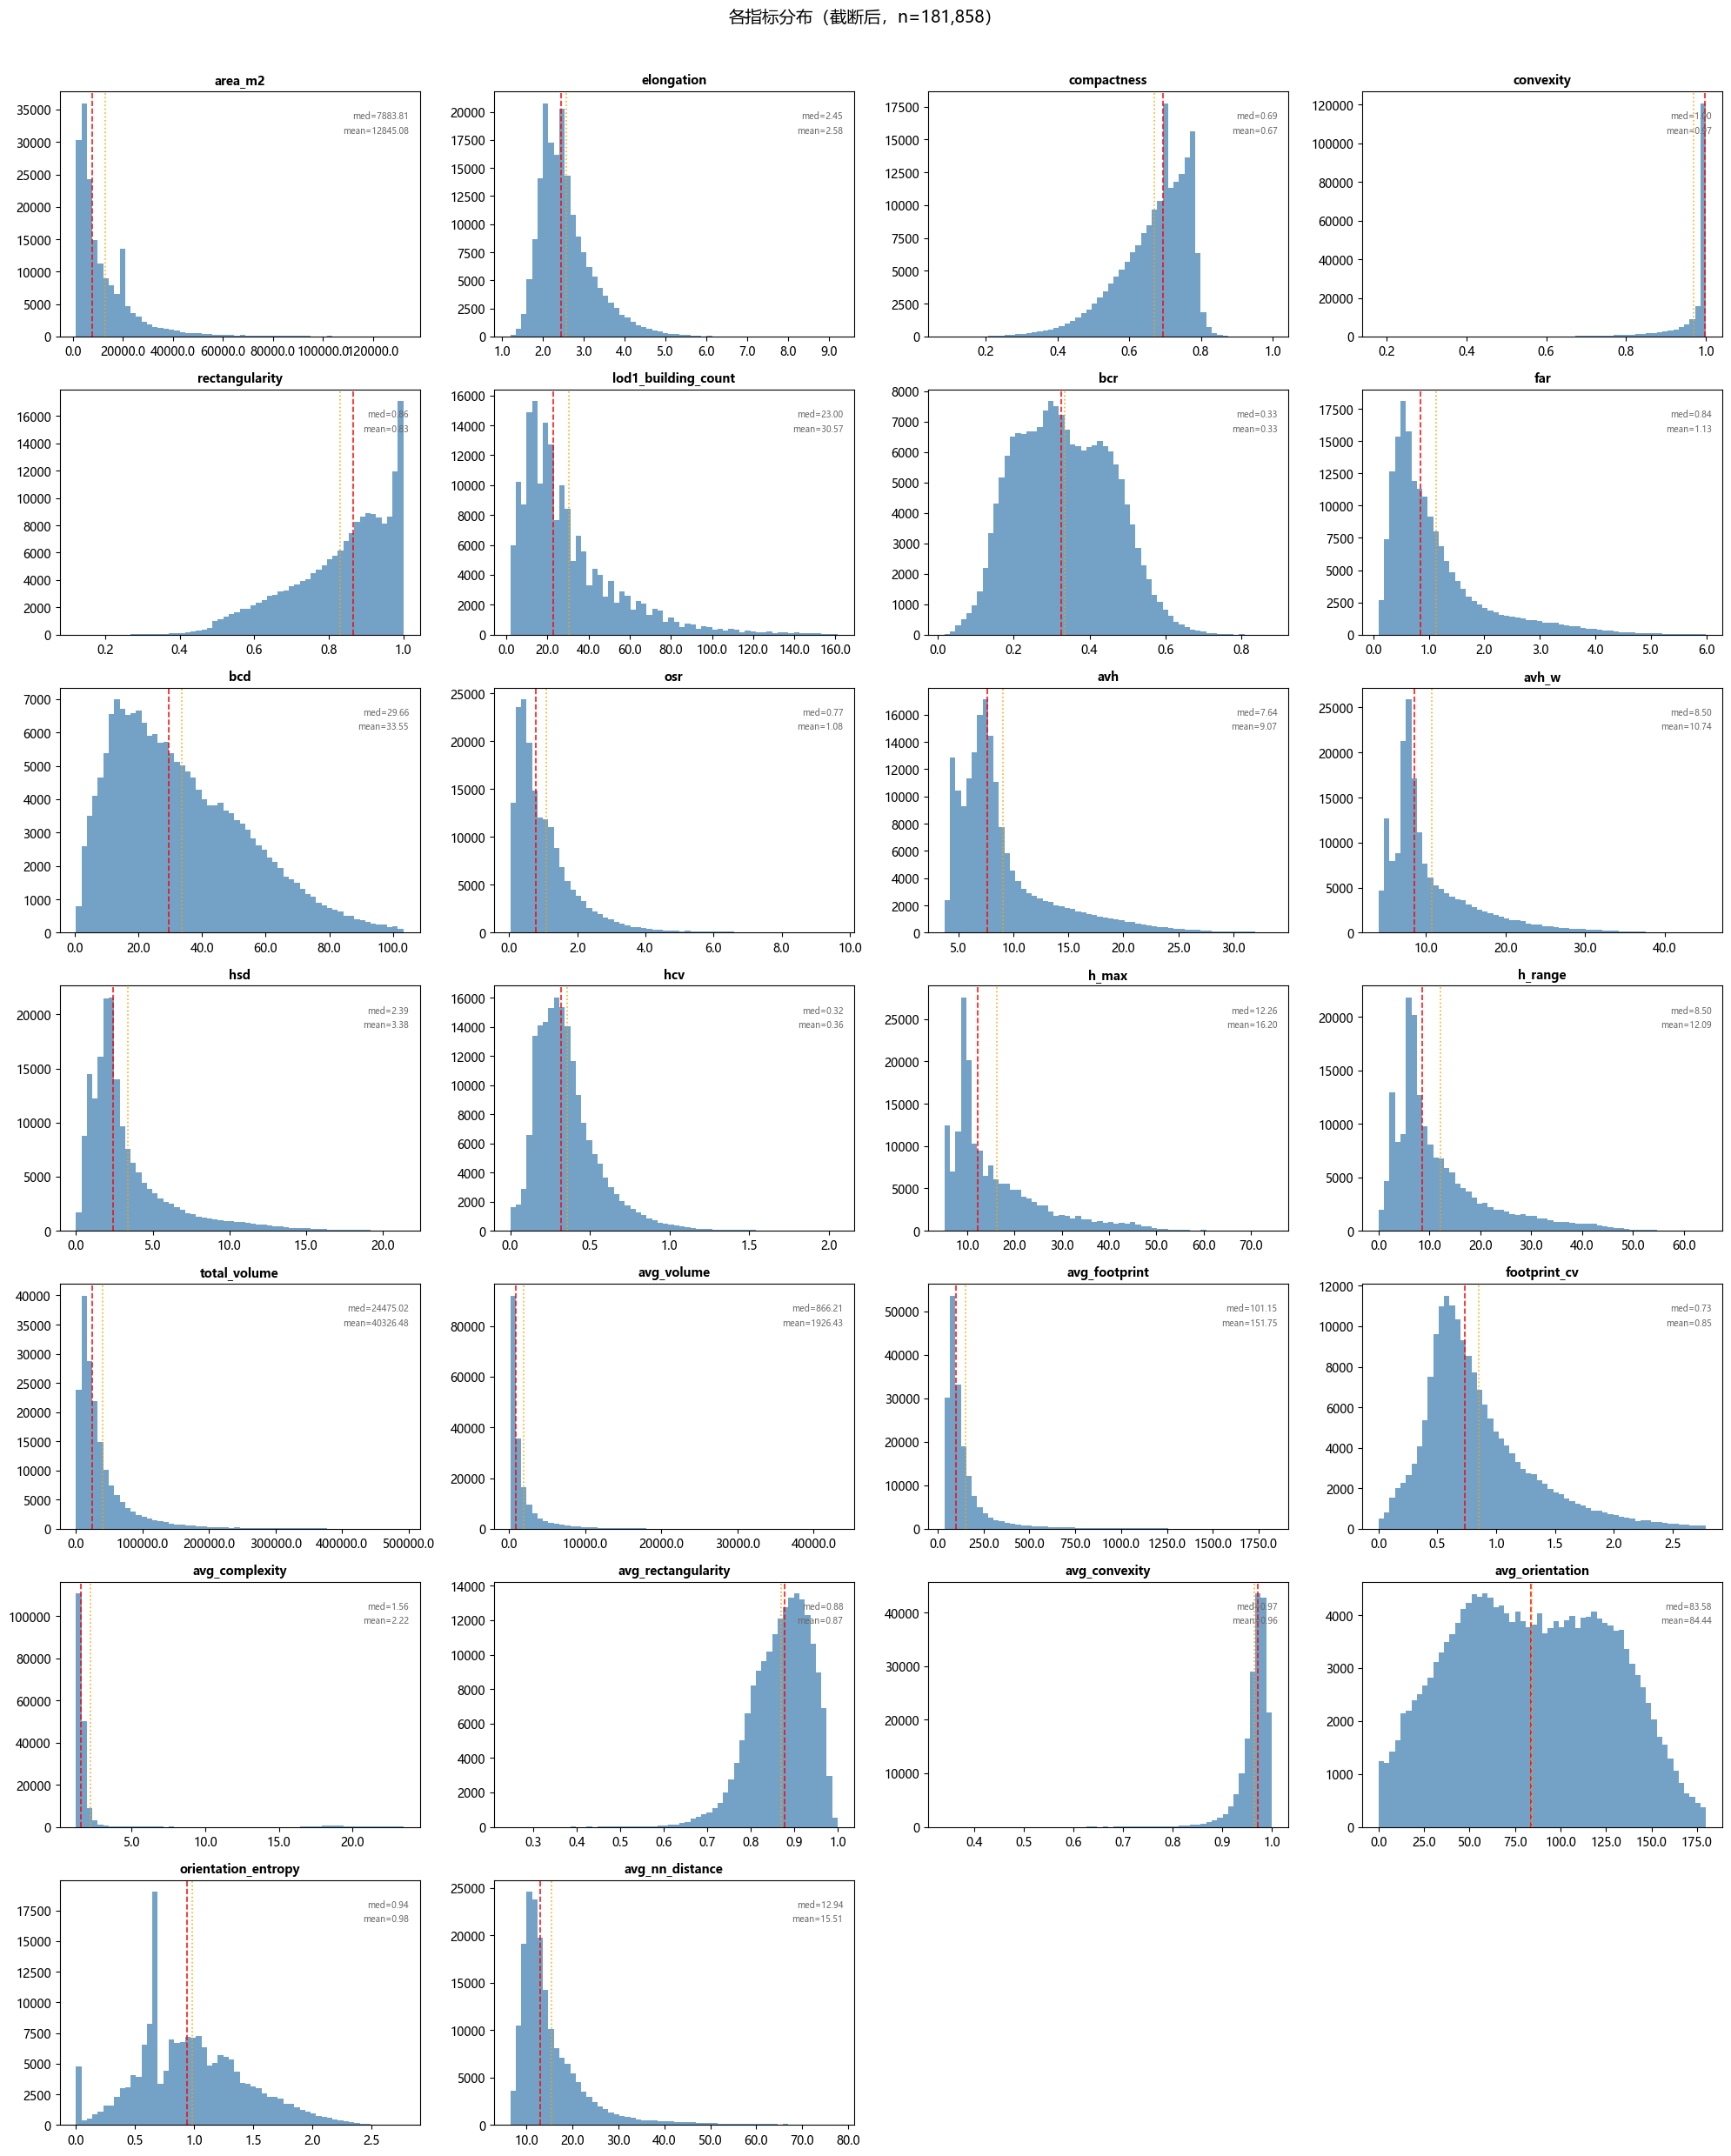

In [21]:
# ══════════════════════════════════════════════
#  截断后各指标分布直方图
# ══════════════════════════════════════════════
os.makedirs("output", exist_ok=True)

n_cols = 4
n_rows = int(np.ceil(len(METRIC_COLS) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 3.5))
axes = axes.flatten()

for i, col in enumerate(METRIC_COLS):
    ax = axes[i]
    data = df_clean[col]          # 直接用截断后数据，无需再次视觉裁剪

    ax.hist(data, bins=60, color='steelblue', alpha=0.75, edgecolor='none')
    ax.set_title(col, fontsize=10, fontweight='bold')
    ax.set_xlabel('')
    ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f'))

    # 标注中位数和均值
    median_val = data.median()
    mean_val   = data.mean()
    ax.axvline(median_val, color='red',    linewidth=1.2, linestyle='--', alpha=0.9, label='median')
    ax.axvline(mean_val,   color='orange', linewidth=1.2, linestyle=':',  alpha=0.9, label='mean')
    ax.text(0.97, 0.92, f'med={median_val:.2f}\nmean={mean_val:.2f}',
            transform=ax.transAxes, ha='right', va='top', fontsize=7,
            color='dimgray', linespacing=1.5)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle(
    f'各指标分布（截断后，n={len(df_clean):,}）',
    fontsize=14, y=1.01
)
plt.tight_layout()
plt.savefig('output/01_distributions_clean.png', dpi=300, bbox_inches='tight')
plt.show()

# 3. Spearman相关矩阵计算与热力图

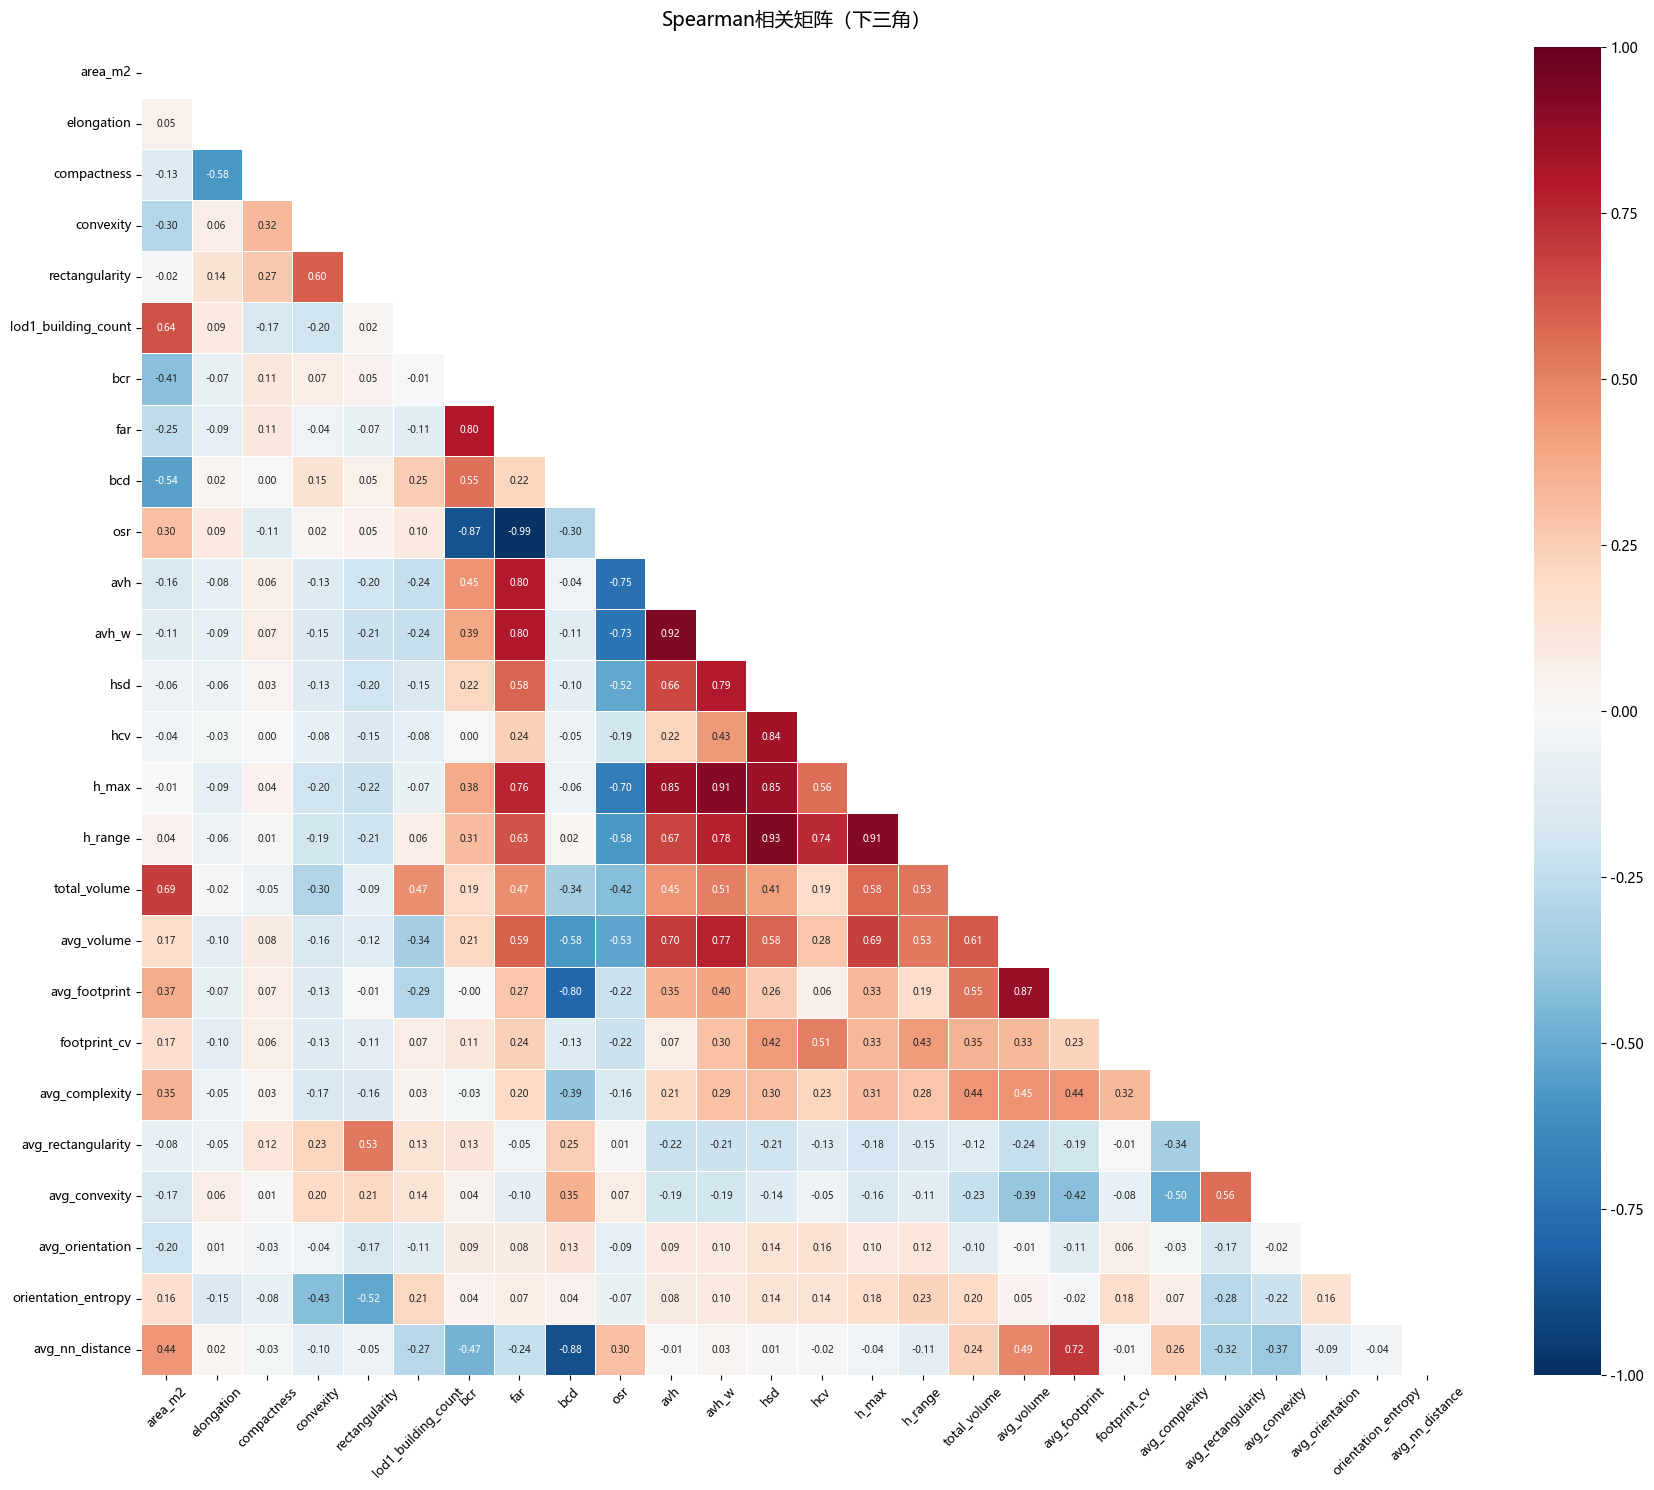

In [23]:
# ── 计算Spearman相关矩阵 ──
corr_matrix = df_clean[METRIC_COLS].corr(method='spearman')

# ── 热力图 ──
fig, ax = plt.subplots(figsize=(18, 15))

mask = np.zeros_like(corr_matrix, dtype=bool)
mask[np.triu_indices_from(mask)] = True  # 只显示下三角，避免重复

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.4,
    linecolor='white',
    annot_kws={'size': 7},
    ax=ax
)

ax.set_title('Spearman相关矩阵（下三角）', fontsize=14, pad=15)
ax.tick_params(axis='x', rotation=45, labelsize=9)
ax.tick_params(axis='y', rotation=0,  labelsize=9)

plt.tight_layout()
plt.savefig('output/02_spearman_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

# 4. 聚类热力图（Clustermap）

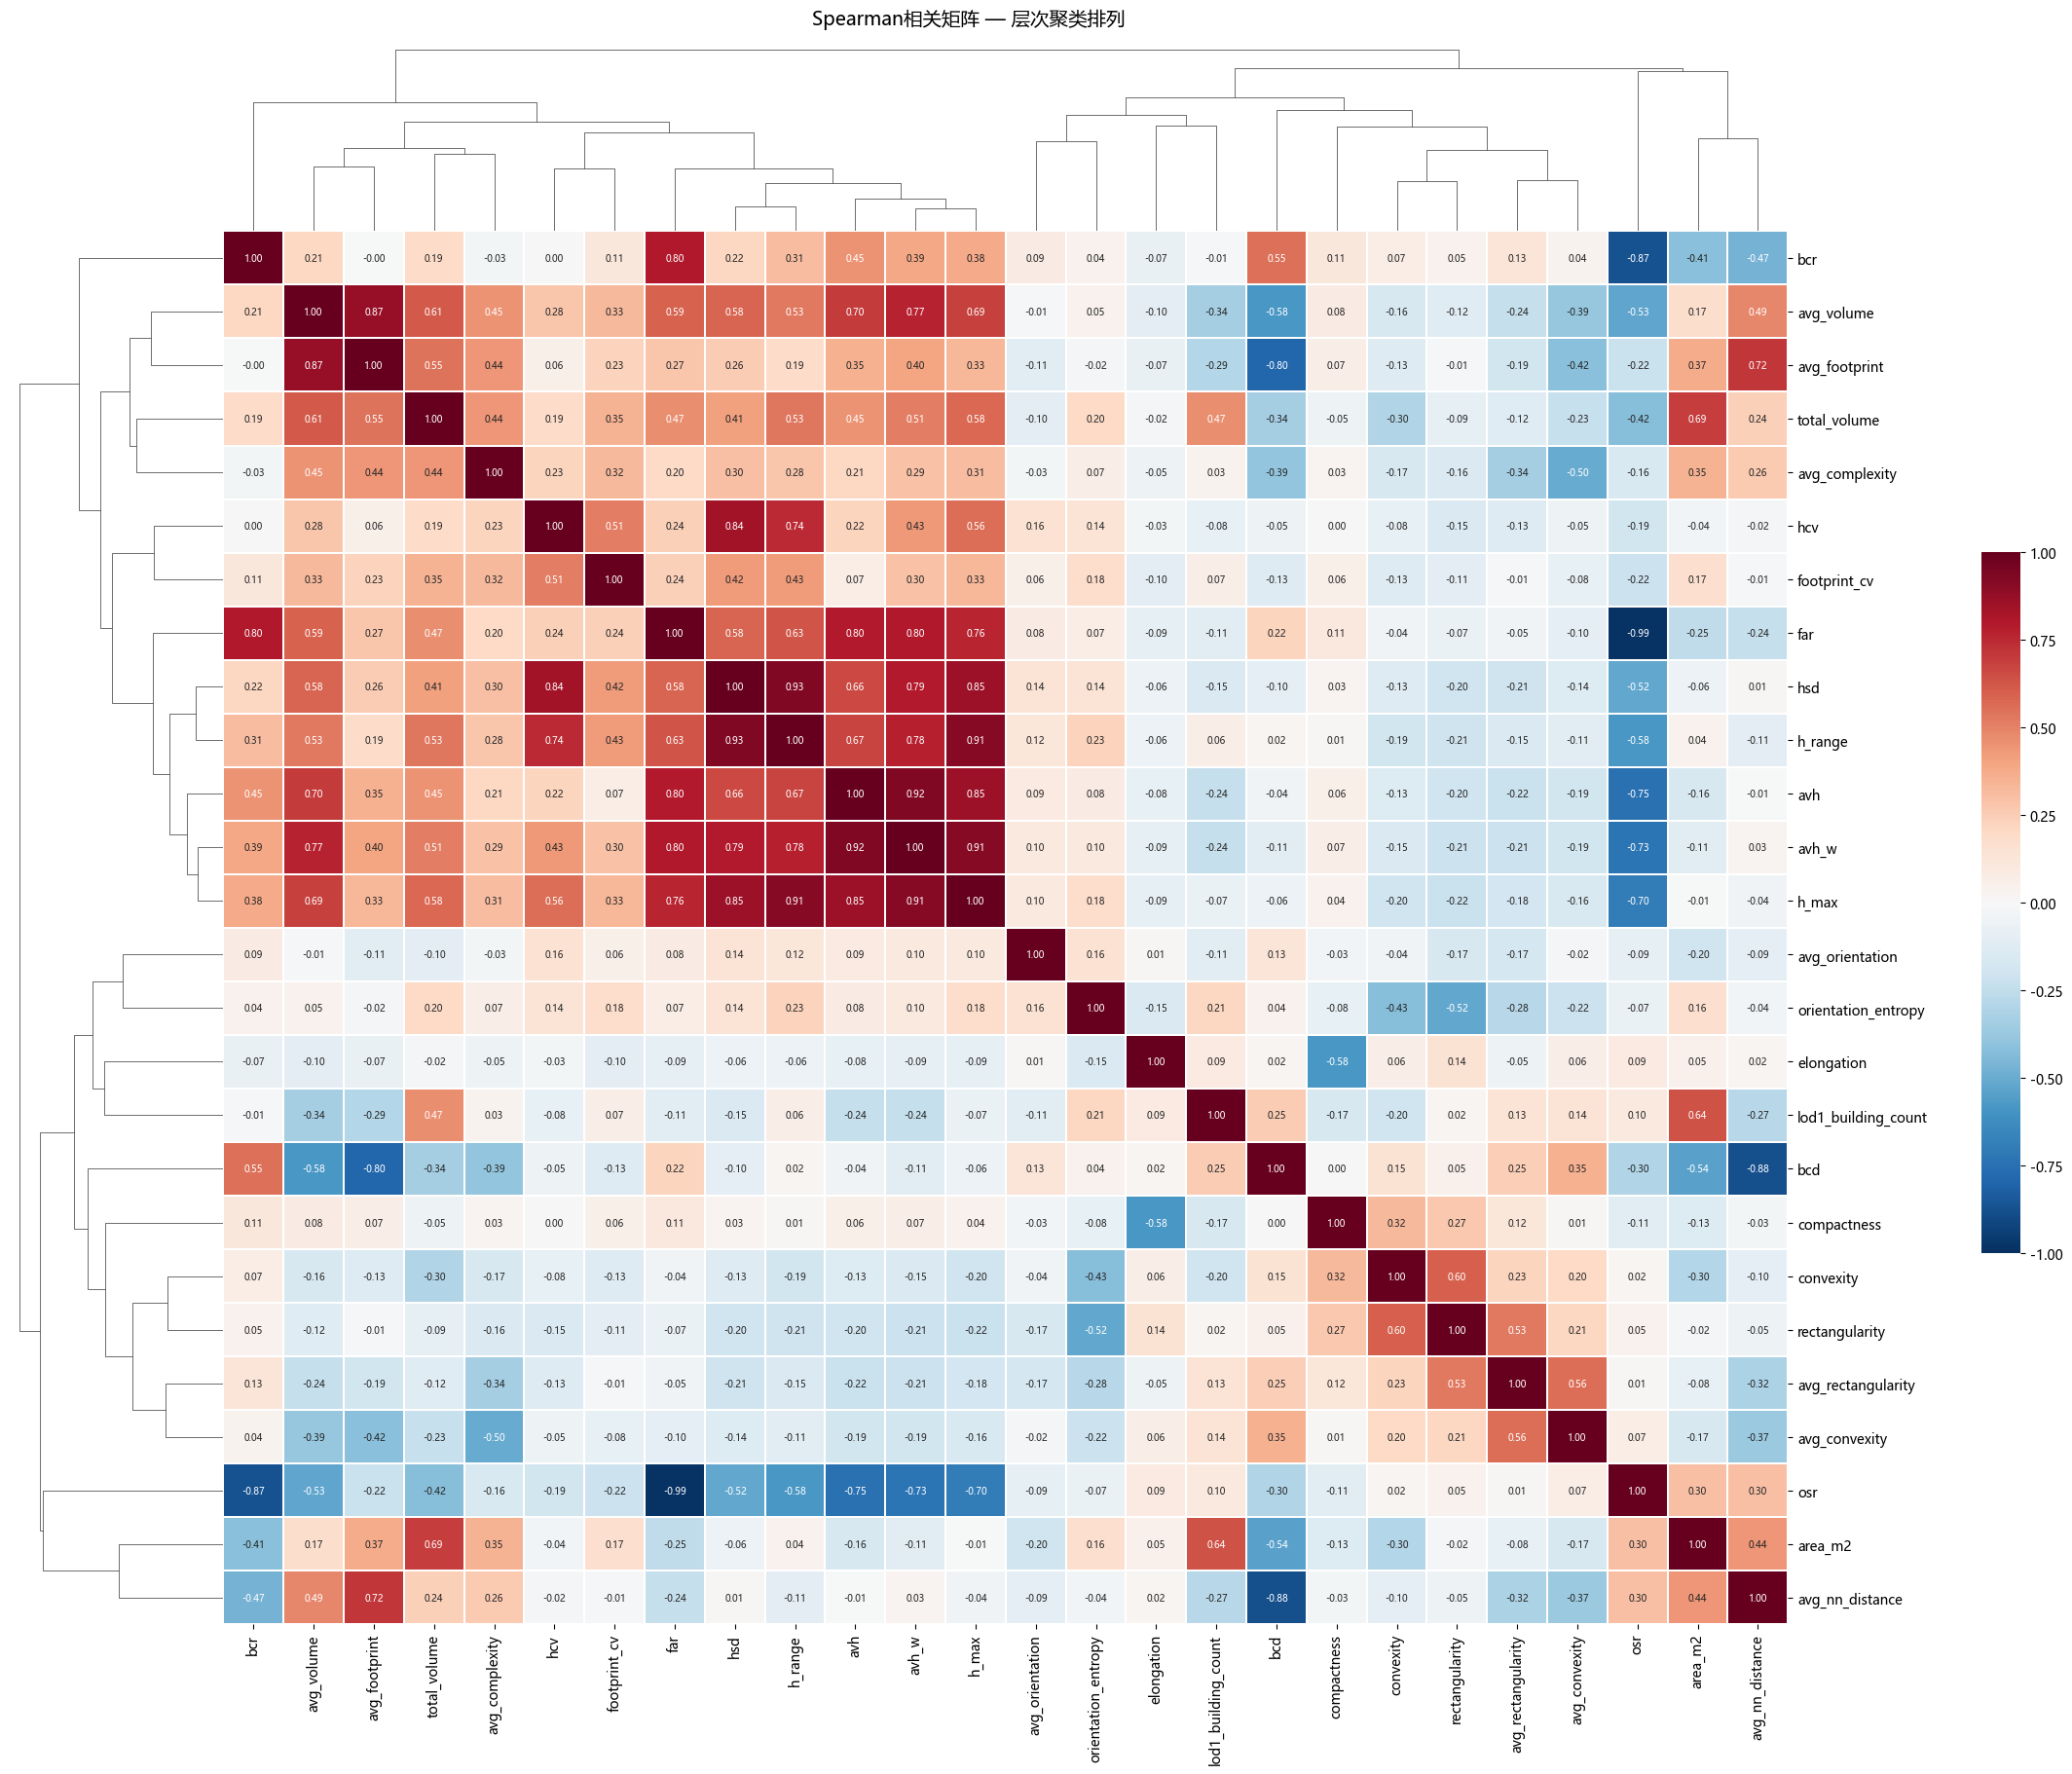

层次聚类后的指标排列顺序：
   1. bcr
   2. avg_volume
   3. avg_footprint
   4. total_volume
   5. avg_complexity
   6. hcv
   7. footprint_cv
   8. far
   9. hsd
  10. h_range
  11. avh
  12. avh_w
  13. h_max
  14. avg_orientation
  15. orientation_entropy
  16. elongation
  17. lod1_building_count
  18. bcd
  19. compactness
  20. convexity
  21. rectangularity
  22. avg_rectangularity
  23. avg_convexity
  24. osr
  25. area_m2
  26. avg_nn_distance


In [24]:
# ── Clustermap ──
g = sns.clustermap(
    corr_matrix,
    method='average',       # 层次聚类的linkage方法
    metric='euclidean',
    cmap='RdBu_r',
    center=0,
    vmin=-1, vmax=1,
    annot=True,
    fmt='.2f',
    annot_kws={'size': 7},
    figsize=(20, 18),
    linewidths=0.3,
    linecolor='white',
    dendrogram_ratio=0.12,  # 树状图占比
    cbar_pos=(1.02, 0.3, 0.02, 0.4)
)

g.fig.suptitle('Spearman相关矩阵 — 层次聚类排列', fontsize=14, y=1.01)
plt.savefig('output/03_spearman_clustermap.png', dpi=300, bbox_inches='tight')
plt.show()

# 打印层次聚类后的指标排列顺序（方便理解分组）
reordered = corr_matrix.columns[g.dendrogram_col.reordered_ind].tolist()
print("层次聚类后的指标排列顺序：")
for i, col in enumerate(reordered):
    print(f"  {i+1:2d}. {col}")

# 5. 高相关指标对提取与筛选决策支持

相关系数 |r| ≥ 0.75 的指标对共 19 组：



,indicator_A,indicator_B,spearman_r
0,far,osr,-0.9901
1,hsd,h_range,0.9250
2,avh,avh_w,0.9229
3,avh_w,h_max,0.9135
4,h_max,h_range,0.9107
5,bcd,avg_nn_distance,-0.8798
6,avg_volume,avg_footprint,0.8718
7,bcr,osr,-0.8700
8,hsd,h_max,0.8534
9,avh,h_max,0.8528



各指标被标记为高相关的次数（参考，非强制删除依据）：


,indicator,flagged_count
3,avh_w,6
0,far,5
4,h_max,5
1,hsd,4
2,avh,3
9,h_range,3
5,bcd,2
7,bcr,2
6,avg_volume,2
8,osr,2


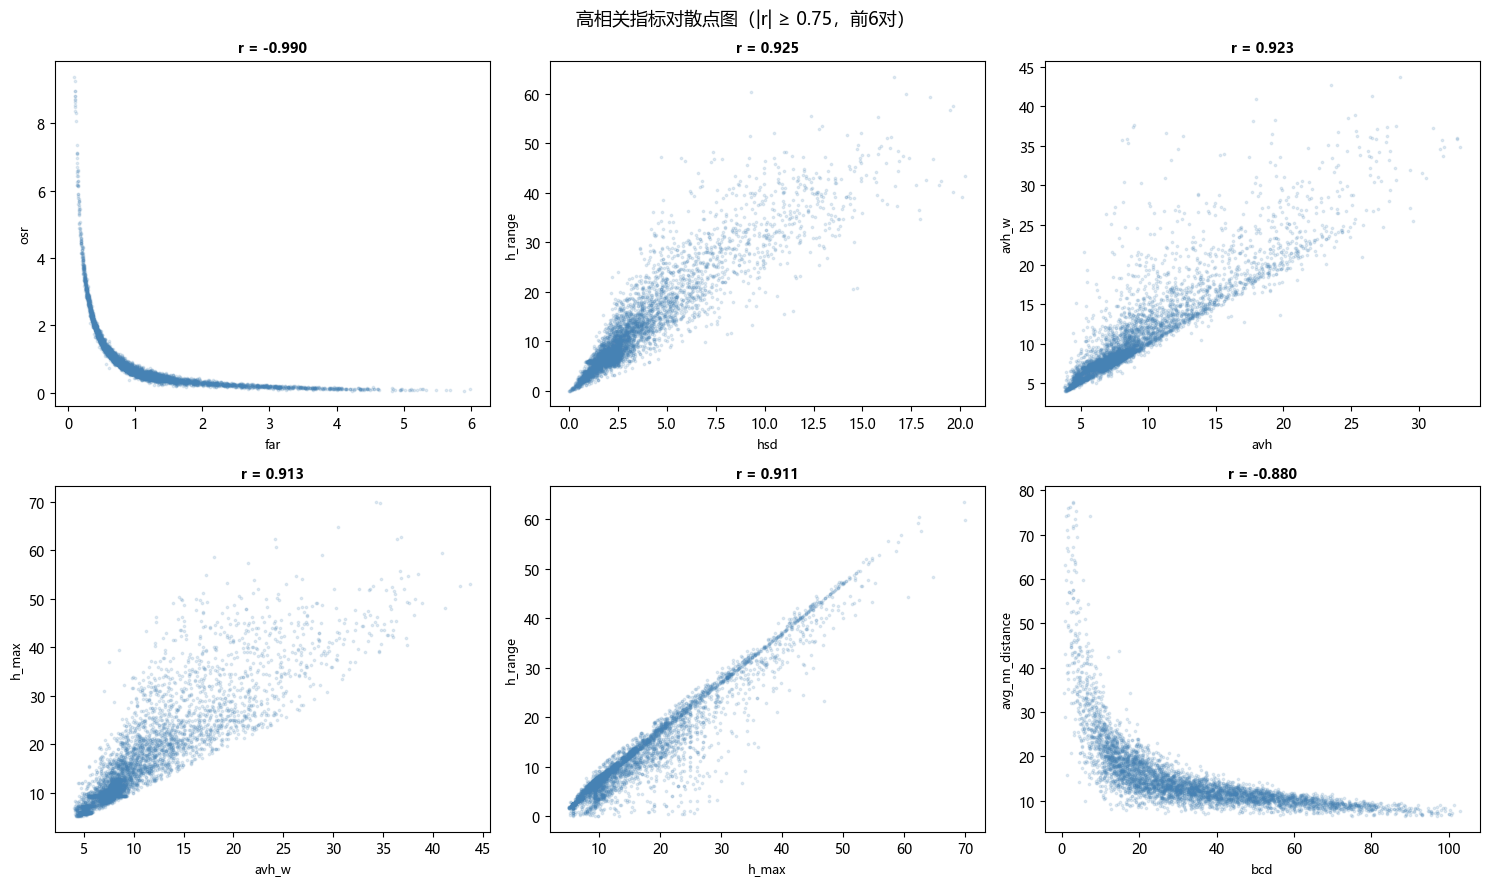

In [25]:
THRESHOLD = 0.75  # 可调整

# ── 提取超过阈值的指标对 ──
corr_pairs = []
cols = corr_matrix.columns.tolist()

for i in range(len(cols)):
    for j in range(i+1, len(cols)):
        r = corr_matrix.iloc[i, j]
        if abs(r) >= THRESHOLD:
            corr_pairs.append({
                'indicator_A': cols[i],
                'indicator_B': cols[j],
                'spearman_r':  round(r, 4),
                'abs_r':       round(abs(r), 4)
            })

df_pairs = pd.DataFrame(corr_pairs).sort_values('abs_r', ascending=False)

print(f"相关系数 |r| ≥ {THRESHOLD} 的指标对共 {len(df_pairs)} 组：\n")
display(df_pairs.drop(columns='abs_r').reset_index(drop=True))

# ── 每个指标被标记的次数（越多越冗余）──
from collections import Counter
flagged = Counter(df_pairs['indicator_A'].tolist() + df_pairs['indicator_B'].tolist())
df_flagged = pd.DataFrame(flagged.items(), columns=['indicator', 'flagged_count'])
df_flagged = df_flagged.sort_values('flagged_count', ascending=False)

print(f"\n各指标被标记为高相关的次数（参考，非强制删除依据）：")
display(df_flagged)

# ── 可视化：高相关对的散点矩阵（选取最高相关的前N对）──
TOP_N = 6
top_pairs = df_pairs.head(TOP_N)

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for idx, row in top_pairs.iterrows():
    ax = axes[list(top_pairs.index).index(idx)]
    a, b = row['indicator_A'], row['indicator_B']
    
    # 随机采样5000个点，避免图太密
    sample = df_clean[[a, b]].sample(min(5000, len(df_clean)), random_state=42)
    
    ax.scatter(sample[a], sample[b], alpha=0.15, s=3, color='steelblue')
    ax.set_xlabel(a, fontsize=9)
    ax.set_ylabel(b, fontsize=9)
    ax.set_title(f'r = {row["spearman_r"]:.3f}', fontsize=10, fontweight='bold')

plt.suptitle(f'高相关指标对散点图（|r| ≥ {THRESHOLD}，前{TOP_N}对）', fontsize=13)
plt.tight_layout()
plt.savefig('output/04_high_corr_pairs.png', dpi=300, bbox_inches='tight')
plt.show()